In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)

import functions.mdata_utils as mdata_utils


2025-10-27 16:09:55.421423: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-27 16:09:55.421821: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-27 16:09:55.487456: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-27 16:10:32.212712: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
import tensorflow as tf
tf.__version__

'2.20.0'

## load mdata

In [3]:
# mdata = mu.read("all_Common_DEtop2500.h5mu")   # processed
# mdata

In [4]:
mdata = mu.read("/ix1/ylee/Yifan_Zhang/Code_data/data_EAE/anndata/all_Common.h5mu")

prefixes_to_remove = ('CMO', 'ENSM',
                      'Trav', 'Traj', 'Trac', 'Trbv', 'Trbj', 
                     'Trbc', 'Trdv', 'Trdj', 'Trdc', 'Trgv', 'Trgj', 'Trgc') 

TCR_gene_mask = mdata.var_names.str.startswith(prefixes_to_remove)
mdata = mdata[:, ~TCR_gene_mask]

mdata['gex'].var_names_make_unique()

sc.pp.normalize_total(mdata['gex'])
sc.pp.log1p(mdata['gex'])

ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)

# by nucleotide acid seq
ir.pp.ir_dist(mdata)
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only")
# ir.tl.clonotype_network(mdata, min_cells=10)

meta_airr = ir.get.airr(mdata['airr'], ["cdr3_aa", "v_call", "j_call"] ,  ('VJ_1', 'VDJ_1'))
mdata.obs = mdata.obs.join(meta_airr)
mdata.update()

# mdata.obs = mdata.obs.reindex(mdata.mod['gex'].obs.index)
mdata

MuData object with n_obs × n_vars = 77660 × 33182
  obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'percent.mt', 'integrated_nn_res.2', 'seurat_clusters', 'level_2_clusters', 'manual_cell_type', 'run_num', 'sample', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call'
  2 modalities
    gex:	77660 x 33182
      obs:	'mouse_id', 'date', 'tissue', 'sample', 'mouse_BC'
      uns:	'log1p'
    airr:	77660 x 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size'
      uns:	'chain_indices', 'ir_dist_nt_identity', 'clone_id'
      obsm:	'airr', 'chain_indices'

## QC

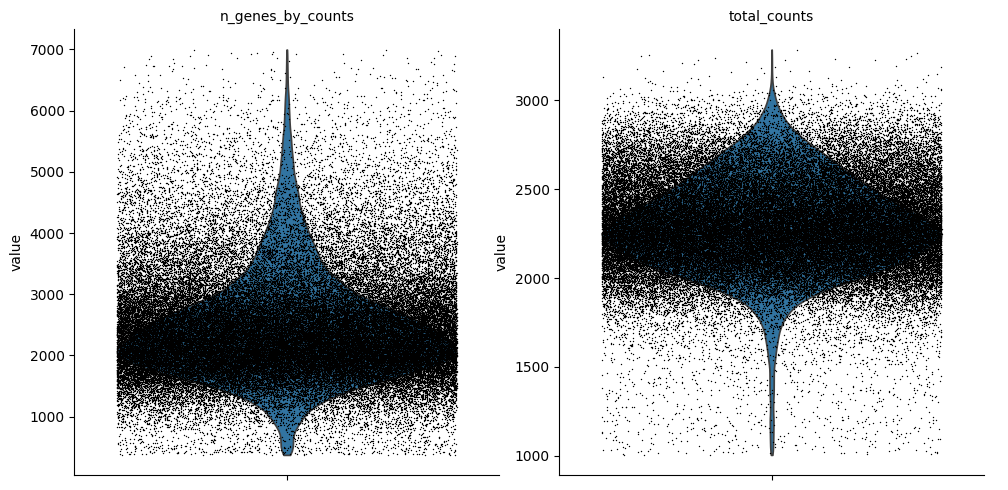

In [5]:
mdata['gex'].var["mt"] = mdata['gex'].var_names.str.startswith("mt-")
# ribosomal genes
mdata['gex'].var["ribo"] = mdata['gex'].var_names.str.startswith(("Rps", "Rpl"))
# hemoglobin genes
mdata['gex'].var["hb"] = mdata['gex'].var_names.str.contains("^Hb[^(p)]")

sc.pp.calculate_qc_metrics(
    mdata['gex'], qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)
# 
sc.pp.filter_cells(mdata['gex'], min_genes= 300)
sc.pp.filter_cells(mdata['gex'], max_genes= 7000)

sc.pp.filter_cells(mdata['gex'], min_counts=1000)
sc.pp.filter_cells(mdata['gex'], max_counts=40000)

sc.pp.filter_genes(mdata['gex'], min_cells=50)

sc.pl.violin(
    mdata['gex'],
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True,
)

In [6]:
sc.pp.highly_variable_genes(mdata['gex'], n_top_genes=2500, batch_key="mouse_id")
mdata.mod['gex'] = mdata['gex'][:, mdata['gex'].var['highly_variable']].copy()

In [7]:
mdata = mdata_utils.sync_mdata_obs(mdata)
mdata

MuData object with n_obs × n_vars = 77500 × 2500
  obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'percent.mt', 'integrated_nn_res.2', 'seurat_clusters', 'level_2_clusters', 'manual_cell_type', 'run_num', 'sample', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call'
  2 modalities
    gex:	77500 x 2500
      obs:	'mouse_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
      uns:	'log1p', 'hvg'
    airr:	77500 x 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size'
      uns:	'chain_indices', 'ir_dist_nt_identity', 'clone_id'
      obsm:	'airr', 'chain_indices'

## Annotation

In [ ]:
sc.pp.pca(mdata["gex"], svd_solver="arpack", n_comps=50)
sc.pp.neighbors(mdata["gex"], n_neighbors = 50)
sc.tl.umap(mdata["gex"], min_dist=0.5, spread=1.0)

In [ ]:
sc.tl.leiden(mdata["gex"], resolution = 1, n_iterations=-1, flavor = 'igraph')
sc.pl.umap(mdata["gex"], color=["tissue", "mouse_id"])

In [ ]:
sc.pl.umap(mdata["gex"], color="leiden", legend_loc="on data")

In [ ]:
type_markers = ['Cd4', 'Cd8a','Cd8b1','Nkg7','Foxp3', 'Ikzf2', 'Ctla4', 'Il2ra','Ccr6', 'Il22']
state_markers = ['Isg15', 'Gbp2', 'Ifih1', 'Icos', 'Cd69', 'Cd28', 'Pdcd1', 'Lag3', 'Havcr2', 'Ccr7', 'Sell', 'Cd27']
myloid_markers = ['Cd11b', 'Cd33', 'Cd45', 'Cd68']
markers_in = []

for i in type_markers:
    if i in mdata["gex"].var_names:
        markers_in.append(i) 
        
mu.pl.embedding(mdata["gex"], basis="umap", color= markers_in,  wspace = 0.1, ncols=2, vmin=0)

In [ ]:
myloid_markers = ['Cd11b', 'Cd33', 'Cd45', 'Cd68']
markers_in = []

for i in myloid_markers:
    if i in mdata["gex"].var_names:
        markers_in.append(i) 
        
mu.pl.embedding(mdata["gex"], basis="umap", color= markers_in,  wspace = 0.1, ncols=2, vmin=0)

In [ ]:
mdata["gex"].obs['modified_cell_type'] = 'NaN'
mdata["gex"].obs['modified_cell_type'][mdata["gex"].obs['leiden'].isin(['2','13','6','14',])] = 'CD8+ T'
mdata["gex"].obs['modified_cell_type'][mdata["gex"].obs['leiden'].isin(['4','7'])] = 'Treg'
mdata["gex"].obs['modified_cell_type'][mdata["gex"].obs['leiden'].isin(['8'])] = 'CD4+ Th17'
mdata["gex"].obs['modified_cell_type'][mdata["gex"].obs['leiden'].isin(['16'])] = 'CD4+ Th1'
mdata["gex"].obs['modified_cell_type'][mdata["gex"].obs['leiden'].isin(['5','1','0','18','8'])] = 'CD4+ T'
mdata["gex"].obs['modified_cell_type'][mdata["gex"].obs['leiden'].isin(['10','11'])] = 'Myloid'

mdata["gex"].obs['modified_cell_type'][mdata["gex"].obs['leiden'].isin(['12','15'])] = 'CD4+ CD8+'

sc.pl.umap(mdata["gex"], color=['modified_cell_type'])

In [ ]:
markers_in = []
for i in state_markers:
    if i in mdata["gex"].var_names:
        markers_in.append(i) 
mu.pl.embedding(mdata, basis="gex:umap", color= markers_in, wspace = 0.1, ncols=2, vmin=0)

In [ ]:
import scanpy as sc

IFN_stim = ['Isg15', 'Gbp2', 'Ifih1']
Activation = ['Icos', 'Cd69', 'Cd28']
Exhaust = ['Pdcd1', 'Lag3', 'Havcr2']
Mem = ['Ccr7', 'Sell', 'Cd27']

sc.tl.score_genes(mdata['gex'], gene_list=IFN_stim, score_name='IFN_stim')
sc.tl.score_genes(mdata['gex'], gene_list=Activation, score_name='Activation')
sc.tl.score_genes(mdata['gex'], gene_list=Exhaust, score_name='Exhaust')
sc.tl.score_genes(mdata['gex'], gene_list=Mem, score_name='Mem')

In [ ]:
# mdata['gex'].obs['state'] = 'Effector'
mdata['gex'].obs.loc[mdata['gex'].obs['Exhaust'] > 0.5, 'state'] = 'Exhausted'
mdata['gex'].obs.loc[mdata['gex'].obs['Mem'] > 0.5, 'state'] = 'Mem'
mdata['gex'].obs.loc[mdata['gex'].obs['IFN_stim'] > 0.5, 'state'] = 'activated'
mdata['gex'].obs.loc[mdata['gex'].obs['Activation'] > 0.5, 'state'] = 'activated'


In [ ]:
sc.pl.umap(mdata["gex"], color=['state'])

## MOG and 2D2 difference

### subclusters

In [ ]:
Treg2D2_idx = (mdata['gex'].obs['mouse_id'].astype('str').isin(['5_3','5_4']))
mdata_2D2 = mdata[Treg2D2_idx.astype('bool')]
mdata_MOG = mdata[~Treg2D2_idx.astype('bool')]

mdata['gex'].obs['is_2D2'] = Treg2D2_idx

In [ ]:
sc.pl.umap(mdata["gex"], color=['is_2D2'])

In [ ]:
### single gene distribution
from scipy.stats import ranksums

for type_i in ['CD4+ T', 'CD8+ T', 'Treg']:
    expr_A = mdata_2D2['gex'][mdata_2D2['gex'].obs['modified_cell_type']== type_i][:, 'Cd4'].X.toarray().flatten()
    expr_B = mdata_MOG['gex'][mdata_MOG['gex'].obs['modified_cell_type']== type_i][:, 'Cd4'].X.toarray().flatten()
    stat, pval = ranksums(expr_A, expr_B)
    print("Wilcoxon rank-sum p-value:", pval)


### Correlations of pseudobulk expression values

In [ ]:
import pandas as pd
from scipy.sparse import issparse
import numpy as np

def to_dense(X):
    if issparse(X):
        return X.toarray()
    return X

def clusters_corr(adata1, adata2):
    common = adata1.var_names.intersection(adata2.var_names)
    a1 = adata1[:, common]
    a2 = adata2[:, common]

    pb1 = to_dense(a1.X).mean(axis=0)
    pb2 = to_dense(a2.X).mean(axis=0)

    df = pd.DataFrame({"group1": pb1, "group2": pb2}, index=common)

    corr_pearson = df["group1"].corr(df["group2"], method="pearson")
    corr_spearman = df["group1"].corr(df["group2"], method="spearman")
    return corr_pearson, corr_spearman

pearson = []
spearman = []
for row_idx, cat1 in enumerate(mdata['gex'].obs['mouse_id'].unique()):
    for col_idx, cat2 in enumerate(mdata['gex'].obs['mouse_id'].unique()):
        if row_idx == col_idx:
            pearson.append(1)
            spearman.append(1)
        else:
            adata1 = mdata['gex'][mdata['gex'].obs['mouse_id']== cat1]
            adata2 = mdata['gex'][mdata['gex'].obs['mouse_id']== cat2]
            stat, pval = clusters_corr(adata1, adata2)
            pearson.append(pval)
            spearman.append(stat)
        
spearman_df = np.array(spearman).reshape([row_idx+1,col_idx+1])

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

disp = ConfusionMatrixDisplay(confusion_matrix= np.tril(spearman_df), display_labels = mdata['gex'].obs['mouse_id'].unique())
disp.plot(cmap='Blues')
plt.title('spearman corr')
plt.show()

## Scirpy EDA

In [ ]:
# ir.pp.ir_dist(
#     mdata,
#     metric="tcrdist",
#     sequence="aa",
#     cutoff=15,
# )

# ir.tl.define_clonotype_clusters(mdata, sequence="aa", metric="tcrdist", receptor_arms="all", dual_ir="any")
# ir.tl.clonotype_network(mdata, min_cells=10, sequence="aa", metric="tcrdist")
# _ = ir.pl.clonotype_network(mdata, color="sample", label_fontsize=9, panel_size=(8,8), base_size=20)


In [ ]:
# Perform clonal expansion analysis
ir.tl.clonal_expansion(mdata)

mdata.obs["celltype_sample"] = (
    mdata['gex'].obs["modified_cell_type"].astype(str) + "_" + mdata.obs["sample"].astype(str)
)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby="celltype_sample",  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

## clonotype dist

In [ ]:
# select cells appear in both CNS and SPL

# thresh on clono size
clone_thresh = 2
mdata.obs['cloned'] = mdata['airr'].obs['clone_id_size'] >= clone_thresh

# Check if appear in two tissues
mdata_cloned = mdata[mdata.obs['cloned']]
clone_tissue_df = mdata_cloned['airr'].obs[['clone_id']].join(mdata_cloned['gex'].obs['tissue'])
clone_tissue_counts = clone_tissue_df.groupby('clone_id')['tissue'].nunique()
multi_tissue_clones = clone_tissue_counts[clone_tissue_counts > 1].index
mdata.obs['in_two_tissue'] = mdata['airr'].obs['clone_id'].isin(multi_tissue_clones)

mdata.obs['in_two_tissue'].value_counts()

## 2D2 TCR dist

In [ ]:
from tcrdist.repertoire import TCRrep
# formating by tcrdist requirements
ref_df = pd.read_csv('data/TCRdist/std_MOG_assays.csv')
ref_df.rename(columns={'Chain 2 CDR3': 'cdr3_b_aa', 'Chain 2 V Gene':'v_b_gene', 
                   'Chain 2 J Gene':'j_b_gene', }, inplace=True)

ref_df['v_b_gene'] = ref_df['v_b_gene'].apply(lambda x: str(x) if str(x).endswith('*01') else str(x) + '*01')
ref_df['j_b_gene'] = ref_df['j_b_gene'].apply(lambda x: str(x) if str(x).endswith('*01') else str(x) + '*01')


In [ ]:
def mdata_TCR_formating(mdata_subset):
    query_df = mdata_subset.obs[['VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call']]
    query_df['cell_id'] = query_df.index
    query_df.dropna(subset = ["VDJ_1_cdr3_aa"])

    query_df.rename(columns={'VDJ_1_cdr3_aa': 'cdr3_b_aa', 'VDJ_1_v_call':'v_b_gene', 
                       'VDJ_1_j_call':'j_b_gene', }, inplace=True)

    # 'VDJ_1_consensus_count':'count'
    # query_df['cdr3_b_aa'] = 'C' + query_df['cdr3_b_aa'].astype(str) + 'F'
    query_df['cdr3_b_aa'] = query_df['cdr3_b_aa'].astype(str)
    
    query_df['v_b_gene'] = query_df['v_b_gene'].str.split('+').str[0]
    query_df['j_b_gene'] = query_df['j_b_gene'].str.split('+').str[0]

    query_df['v_b_gene'] = query_df['v_b_gene'].apply(lambda x: str(x) if str(x).endswith('*01') else str(x) + '*01')
    query_df['j_b_gene'] = query_df['j_b_gene'].apply(lambda x: str(x) if str(x).endswith('*01') else str(x) + '*01')

    # query_df_clones = query_df_clones.drop(columns=["cell_id"])
    query_df_unique = query_df.drop_duplicates(['cdr3_b_aa'])
    return query_df_unique


In [ ]:
def TCRdist_to_ref(ref_df, query_df_unique):
    tr_ref = TCRrep(cell_df = ref_df, 
                organism = 'mouse', 
                chains = ['beta'],
                compute_distances = False,)

    tr_q = TCRrep(cell_df = query_df_unique, 
                organism = 'mouse', 
                chains = ['beta'],
                compute_distances = False,)

    tr_ref.compute_rect_distances(tr_ref.clone_df,  tr_q.clone_df)
    print(tr_ref.rw_beta.shape)
    print(tr_ref.rw_beta)
    return tr_ref, tr_q


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

tr_list = []
dist_thres = 85
mdata_sub = mdata[mdata.obs['in_two_tissue']]

m_list = [mdata, mdata_sub]
tcrDist_list = []

for mdata_sub in m_list:
    # 'in_two_tissue' ,  'cloned'
    query_df = mdata_TCR_formating(mdata_sub)

    tr_out, tr_query = TCRdist_to_ref(ref_df, query_df)
    tr_list.append(tr_out)

    flat_arr = tr_out.rw_beta.min(axis=0).flatten()
    TCR_all = tr_query.clone_df
    TCR_all['TCRdist_MOG'] = flat_arr
    
    tcrDist_list.append(TCR_all)
    plt.hist(flat_arr, bins=50, density=True, alpha=0.4)
    selected_clone_id = flat_arr < dist_thres
    TCR_selected = TCR_all[selected_clone_id]
    
plt.xlim([0, 175])
plt.legend(['two tissue', 'one tissue'])
plt.title("Histogram of 2D Array Elements")
plt.xlabel("Distance")
plt.ylabel("Density")
plt.show()    

In [ ]:
TCR_all = tcrDist_list[0]
sub_2d2 = TCR_all[TCR_all['cdr3_b_aa']=='ASSLDCGANP']
sub_2d2

In [ ]:
#### 2D2 seq not found in EAE TCR repertoire   #####

In [ ]:
mdata.obs = (
    mdata.obs.merge(
        TCR_all[['cdr3_b_aa', 'TCRdist_MOG']],
        how='left',
        left_on='VDJ_1_cdr3_aa',
        right_on='cdr3_b_aa'
    )
    .drop(columns=['cdr3_b_aa'])
    .set_index(mdata.obs.index)   # restore original index
)

mdata.obs['TCRdist_MOG']

In [ ]:
### save data   ###
mdata.write('all_common_DE2500_metaData.h5mu')

In [ ]:
aa

In [ ]:
type_markers = ['Cd4', 'Cd8a','Cd8b1','Nkg7','Foxp3', 'Ikzf2', 'Ctla4', 'Il2ra','Ccr6', 'Il22']
state_markers = ['Isg15', 'Gbp2', 'Ifih1', 'Icos', 'Cd69', 'Cd28', 'Pdcd1', 'Lag3', 'Havcr2', 'Ccr7', 'Sell', 'Cd27']
markers_in = []

mdata_temp = mdata[mdata.obs['in_two_tissue']]
for i in state_markers:
    if i in mdata_temp["gex"].var_names:
        markers_in.append(i) 
markers_in

In [ ]:
# clone_thresh = 3
# mdata.obs['cloned'] = (
#     mdata['airr'].obs['clone_id_size'] >= clone_thresh
# ).values

# # Check if appear in two tissues
# mdata_cloned = mdata[mdata.obs['cloned']]
# clone_tissue_df = mdata['airr'].obs[['clone_id']].join(mdata_cloned['gex'].obs['tissue'])
# clone_tissue_counts = clone_tissue_df.groupby('clone_id')['tissue'].nunique()
# multi_tissue_clones = clone_tissue_counts[clone_tissue_counts > 1].index

# mdata.obs['in_two_tissue'] = mdata['airr'].obs['clone_id'].isin(multi_tissue_clones)
# mdata.obs['in_two_tissue']

In [ ]:
import scanpy as sc
sc.pp.pca(mdata_temp["gex"], svd_solver="arpack", n_comps=10)
sc.pp.neighbors(mdata_temp["gex"], use_rep='X_pca', n_neighbors = 10)
sc.tl.umap(mdata_temp["gex"], min_dist=0.5, spread=1.0)

In [ ]:
mdata_temp.obs['is_sim'] = 'mid'
mdata_temp.obs['is_sim'][mdata_temp.obs['TCRdist_MOG'] < 100] = 'True'
mdata_temp.obs['is_sim'][mdata_temp.obs['TCRdist_MOG'] > 140] = 'False'

# mdata_temp = mdata_temp[mdata_temp.obs['is_sim'].isin(['True', 'False'])]


In [ ]:
## subseting
mdata_temp.update()
# mdata_sub = mdata_temp[ (mdata_temp.obs['cloned']) & (~mdata_temp.obs['in_two_tissue'])]

mdata_sub = mdata_temp[mdata_temp.obs['in_two_tissue']]

# mdata_sub = mdata_temp[mdata_temp.obs['cloned']]    

# mdata_sub = mdata_temp

group_name = 'is_sim'
mdata_sub['gex'].obs[group_name] = mdata_sub.obs[group_name].astype('category')
mdata_sub['gex'].obs[group_name].value_counts()

In [ ]:
sc.pl.umap(mdata_sub["gex"], color=["tissue", 'is_sim'])

## DAE plot

In [ ]:
groups = ['True', 'False']
sc.tl.rank_genes_groups(mdata_sub['gex'], groupby = group_name, groups=groups, method="wilcoxon")
df = sc.get.rank_genes_groups_df(mdata_sub['gex'], group = 'True')


In [ ]:
sc.pl.rank_genes_groups_dotplot(mdata_sub['gex'], groupby=group_name, groups=groups,
                                    cmap='Blues')
# var_names=markers_in,

In [ ]:
df_true = df.head(10)
df_true

In [ ]:
df_false = sc.get.rank_genes_groups_df(mdata_sub['gex'], group = 'False').head(10)
df_false

In [ ]:
pval_type = df[df["names"].isin(type_markers)]
pval_type["gene"] = pd.Categorical(pval_type["names"], categories=type_markers, ordered=True)
pval_type = pval_type.sort_values("gene")
pval_type

In [ ]:
var_group_positions = [(0,0), (1,3), (4, 7), (8, 9)]   # inclusive start, inclusive end
var_group_labels = ["CD4 T", "CD8 T", "Treg", "Th17"]

dp = sc.pl.dotplot(
    mdata_sub['gex'], var_names=type_markers, groupby=group_name, cmap="Blues",
    var_group_positions=var_group_positions,
    var_group_labels=var_group_labels,
    show=False, return_fig=True
)
dp.make_figure()

def p2stars(p):
    if p < 1e-4: return "****"
    elif p < 1e-3: return "***"
    elif p < 1e-2: return "**"
    elif p < 5e-2: return "*"
    else: return ""

    # dict (or Series) of p-values per gene (fill with yours)
pvals = dict(zip(pval_type['names'], pval_type['pvals'])) # example; replace with real p-values
ax = dp.get_axes()["mainplot_ax"]

# get current tick labels
yticklabels = [t.get_text() for t in ax.get_xticklabels()]

# prepend stars to gene names
new_labels = [f"{p2stars(pvals.get(g,1))}  {g}" for g in yticklabels]
ax.set_xticklabels(new_labels)
plt.show()

In [ ]:
pval_state = df[df["names"].isin(markers_in)]
pval_state["gene"] = pd.Categorical(pval_state["names"], categories=markers_in, ordered=True)
pval_state = pval_state.sort_values("gene")
pval_state

In [ ]:
var_group_positions = [(0,2), (3,5), (6,8), (9, 9)]   # inclusive start, inclusive end
var_group_labels = ["IFN stim", "act", "Exhaust", "Central mem"]

dp = sc.pl.dotplot(
    mdata_sub['gex'], var_names=markers_in, groupby=group_name, cmap="Blues",
    var_group_positions=var_group_positions,
    var_group_labels=var_group_labels,
    show=False, return_fig=True
)
dp.make_figure()

# dict (or Series) of p-values per gene (fill with yours)
pvals =  dict(zip(pval_state['names'], pval_state['pvals'])) # example; replace with real p-values

ax = dp.get_axes()["mainplot_ax"]

# get current tick labels
yticklabels = [t.get_text() for t in ax.get_xticklabels()]

# prepend stars to gene names
new_labels = [f"{p2stars(pvals.get(g,1))}  {g}" for g in yticklabels]
ax.set_xticklabels(new_labels)
plt.show()

In [ ]:
## subset by TCR dist
mdata_temp = mdata_temp[mdata_temp.obs['VDJ_1_cdr3_aa'].isin(TCR_selected['cdr3_b_aa_trimed'])]
mdata_temp                    

In [ ]:
# mdata_subset = mdata
import scanpy as sc
sc.pp.pca(mdata_temp["gex"], svd_solver="arpack", n_comps=10)
sc.pp.neighbors(mdata_temp["gex"], use_rep='X_pca', n_neighbors = 10)
sc.tl.umap(mdata_temp["gex"], min_dist=0.5, spread=1.0)
sc.tl.leiden(mdata_temp["gex"], resolution = 0.5, n_iterations=2, flavor = 'igraph')
sc.pl.umap(mdata_temp["gex"], color=["tissue"])

In [ ]:
mdata_temp.obs['manual_cell_type'] = mdata_temp.obs['manual_cell_type'].cat.remove_unused_categories()
mu.pl.embedding(mdata_temp, basis="gex:umap", color= ['manual_cell_type', 'gex:mouse_id'], wspace = 0.2, ncols=2, vmin=0)

In [ ]:
chemokine_all = [g for g in mdata_temp["gex"].var_names if g.startswith(("Cc", "Cxc", "Cx3c"))]

# markers_in = []
# for i in chemokine:
#     if i in mdata_subset["gex"].var_names:
#         markers_in.append(i) 

In [ ]:
sc.tl.rank_genes_groups(mdata_temp["gex"], groupby ="tissue",  method="wilcoxon")
# mask_var = chemokine_all,

# sc.pl.rank_genes_groups_heatmap(mdata_subset["gex"], groupby = "tissue", gene_symbols= chemokine_all,
#                                  cmap='bwr',)

In [ ]:
# Get results as DataFrame
df = sc.get.rank_genes_groups_df(mdata_temp["gex"], group="CN")

# Filter to certain genes
df_filtered = df[df["names"].isin(chemokine_all)]

print(df_filtered.head(5))

In [ ]:
chemokine_topDE = df_filtered['names'].head(10)

mu.pl.embedding(mdata_temp, basis="gex:umap", color= chemokine_topDE[:4], ncols=2, vmin=0)

In [ ]:
expr_chemokine = mdata['gex'][:, chemokine_topDE.values].to_df()
expr_chemokine

In [ ]:
type_markers = ['Cd4', 'Cd8a','Cd8b1','Nkg7','Foxp3', 'Ikzf2', 'Ctla4', 'Il2ra','Ccr6', 'Il22']
state_markers = ['Isg15', 'Gbp2', 'Ifih1', 'Icos', 'Cd69', 'Cd28', 'Pdcd1', 'Lag3', 'Havcr2', 'Ccr7', 'Sell', 'Cd27']
markers_in = []

for i in state_markers:
    if i in mdata["gex"].var_names:
        markers_in.append(i) 
markers_in
expr_markers = mdata['gex'][:, markers_in].to_df()
expr_markers.to_csv('marker_genes_for_training.csv')

In [ ]:
# expr_chemokine.to_csv('top10_chemok.csv')

In [ ]:
sc.pl.rank_genes_groups_dotplot(mdata_temp["gex"],  groupby="tissue", 
                                   var_names=chemokine_topDE[:10], cmap='Blues')


In [ ]:
vars_target_df = pd.read_csv('top10_chemok.csv')
sc.pl.rank_genes_groups_dotplot(mdata_temp["gex"],  groupby="tissue", 
                                   var_names=vars_target_df.columns[1:], cmap='Purples')    # 'Greens', 'Reds', 'Purples'


In [ ]:
TCR_matched = matrix[matrix['cdr3_b_aa'].isin(TCR_selected['cdr3_b_aa'])]
TCR_matched

In [ ]:
TCR_matched['manual_cell_type'].value_counts()

In [ ]:
TCR_matched['sample'].value_counts()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

EM_dim = 97
# max = 97
EM_matrix = TCR_matched.iloc[:,1:EM_dim]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(EM_matrix)

k = 10  # Number of clusters
kmeans = KMeans(n_clusters=k, random_state=42, copy_x=False)
clusters = kmeans.fit_predict(X_scaled)

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=20, svd_solver='randomized', random_state=42)
X_pca_GIANA = pca.fit_transform(X_scaled)

import umap
umap = umap.UMAP(n_components=2, random_state=42, n_neighbors = 20, min_dist = 0.5)
# umap = umap.UMAP(n_components=2, random_state=42)

X_r = umap.fit_transform(X_pca_GIANA)

In [ ]:
# plot
import seaborn as sns

fig, axes = plt.subplots(2,2, figsize=(10,10))

# Create DataFrame
df = pd.DataFrame({
    'x': X_r[:, 0],
    'y': X_r[:, 1],
    'label': TCR_matched['sample']
})
sns.scatterplot(data=df, x='x', y='y', hue='label', s=10, ax = axes[0][0])

df2 = pd.DataFrame({
    'x': X_r[:, 0],
    'y': X_r[:, 1],
    'label': TCR_matched['manual_cell_type']
})
sns.scatterplot(data=df2, x='x', y='y', hue='label', s=10, ax = axes[0][1])

df3 = pd.DataFrame({
    'x': X_r[:, 0],
    'y': X_r[:, 1],
    'label': clusters
})
sns.scatterplot(data=df3, x='x', y='y', hue='label', s=10, palette="deep", ax = axes[1][0])


In [ ]:
%cd /ihome/ylee/yiz133/Code/deepTCR/unSupervised_cluster

In [ ]:
# Create a sample 2D matrix
matrix = pd.read_csv('DTCRU_extracted_features_96_0605.csv', sep = ',')
matrix.drop(columns={'Label'}, inplace=True)

matrix['CDR3_Beta'] = matrix['CDR3_Beta'].str[1:-1]

matrix = pd.merge(matrix, TCR_selected, left_on='CDR3_Beta', right_on='cdr3_b_aa', how='inner')

In [ ]:
m_right = mdata.obs[['VDJ_1_cdr3_aa','manual_cell_type','sample']]
m_right['BC'] = mdata.obs.index
deepTCR_matrix = pd.merge(matrix, m_right, left_on='CDR3_Beta', right_on = 'VDJ_1_cdr3_aa', how='inner')
deepTCR_matrix

In [ ]:
deepTCR_matrix['manual_cell_type'].value_counts()

In [ ]:
deepTCR_matrix['sample'].value_counts()

In [ ]:
EM_dim = 97
EM_matrix_deepTCR = deepTCR_matrix.iloc[:,3:EM_dim]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(EM_matrix_deepTCR)

k = 10  # Number of clusters
kmeans = KMeans(n_clusters=k, random_state=42, copy_x=False)
clusters = kmeans.fit_predict(X_scaled)

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=20, svd_solver='randomized', random_state=42)

from sklearn.decomposition import KernelPCA
kpca = KernelPCA(n_components=30, kernel='rbf', gamma=0.1)

# generate features
# from sklearn.preprocessing import PolynomialFeatures
# poly = PolynomialFeatures(degree=2, include_bias=False)
# EM_matrix_deepTCR = poly.fit_transform(EM_matrix_deepTCR)

import umap
umap = umap.UMAP(n_components=2, random_state=42, n_neighbors = 20, min_dist = 0.5)
# umap = umap.UMAP(n_components=2, random_state=42)

# transform
X_pca_deepTCR = kpca.fit_transform(EM_matrix_deepTCR)
X_r = umap.fit_transform(X_pca_deepTCR)


In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

# Create DataFrame
df = pd.DataFrame({
    'x': X_r[:, 0],
    'y': X_r[:, 1],
    'label': deepTCR_matrix['sample']
})
sns.scatterplot(data=df, x='x', y='y', hue='label', s=30, ax = axes[0])

df2 = pd.DataFrame({
    'x': X_r[:, 0],
    'y': X_r[:, 1],
    'label': deepTCR_matrix['manual_cell_type']
})
sns.scatterplot(data=df2, x='x', y='y', hue='label', s=20, ax = axes[1])


In [ ]:
# GIANA emb
# M = matrix.copy()

# deepTCR emb
M = deepTCR_matrix.copy()
M_embs = M.iloc[:,3:99]
M_obs = M.drop(M.columns[3:99], axis=1)

kpca = KernelPCA(n_components=30, kernel='rbf', gamma=0.1)
M_embs = kpca.fit_transform(M_embs)

M_obs['tissue'] = M_obs['sample'].str[:3]

In [ ]:
import anndata as ad

adata_embs = ad.AnnData(M_embs)
adata_embs.obs = M_obs

adata_embs

In [ ]:
sc.tl.rank_genes_groups(adata_embs, groupby = "tissue", reference = 'SPL')
    
sc.pl.rank_genes_groups_violin(adata_embs,  n_genes=5)

In [ ]:
aaa

## cluster DEA with decoupleR

In [ ]:
import decoupler as dc
dc.__version__

In [ ]:
aa
collectri = dc.op.collectri(organism="mouse")
ri_merged = collectri.groupby('source').agg({
    'weight': 'mean',         # average of numbers
    'target': lambda x: '|'.join(x)  # join with |
}).reset_index()

ri_merged

In [ ]:
# combined = df.groupby('col1')['col2'].sum()
# combined

In [ ]:
dc.mt.ulm(data=mdata['gex'], net=collectri)
score = dc.pp.get_obsm(adata=mdata['gex'], key="score_ulm")

In [ ]:
score.obsm['score_ulm']

In [ ]:
tf = "Ar"
sc.pl.umap(score, color=[tf, "modified_cell_type"], cmap="RdBu_r", vcenter=0, title=[f"{tf} score", "celltype"])

In [ ]:
from sklearn.decomposition import PCA
import umap
import igraph as ig
import leidenalg

pca = PCA(n_components=25, random_state=42)
X_pca = pca.fit_transform(X_scaled)

umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_pca)

In [ ]:
from sklearn.neighbors import NearestNeighbors

# Compute the k-nearest neighbors
knn = NearestNeighbors(n_neighbors=15)
knn.fit(X_pca)
adj_matrix = knn.kneighbors_graph(X_pca, mode='connectivity')

In [ ]:
# Convert the adjacency matrix to a CSR format if it's not already
adj_csr = adj_matrix.tocsr()

# Create an igraph graph from the adjacency matrix
sources, targets = adj_csr.nonzero()
edges = list(zip(sources, targets))
g = ig.Graph(edges=edges, directed=False)


In [ ]:
partition = leidenalg.find_partition(g, leidenalg.ModularityVertexPartition)
labels = np.array(partition.membership)


In [ ]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='tab10', s=10)
plt.title('UMAP Projection with Leiden Clustering')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.colorbar(scatter, label='Cluster')
plt.show()


In [ ]:
import anndata as ad
import scanpy as sc

EM_matrix = EM_matrix.dropna()
adata = ad.AnnData(EM_matrix)
# adata.obs['cluster'] = clusters
adata.obs['tissue'] = tissue
adata.obs['AA_seq'] = matrix.iloc[:,1]
adata


In [ ]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)


In [ ]:
np.isnan(adata.X).any()

In [ ]:
nan_indices = np.argwhere(np.isnan(adata.X))
nan_indices

In [ ]:
sc.pp.pca(adata, svd_solver="arpack", n_comps=20)
sc.pp.neighbors(mdata["gex"], n_neighbors = 20)
sc.tl.umap(mdata["gex"], min_dist=0.5, spread=1.0)
sc.tl.leiden(mdata["gex"], resolution = 0.5, n_iterations=2, flavor = 'igraph')
sc.pl.umap(mdata["gex"], color=["leiden"])


## GSEA

In [ ]:
from scipy import stats
import gseapy as gp

In [ ]:
# Requirements
# pip install scanpy gseapy pandas matplotlib

import scanpy as sc
import pandas as pd
import numpy as np
import gseapy as gp
import os
import matplotlib.pyplot as plt

adata = mdata["gex"]    # <-- your AnnData (mouse)
assert hasattr(adata, "obs") and hasattr(adata, "var"), "mdata['gex'] must be an AnnData"

# Quick checks
print("AnnData shape:", adata.shape)
print("obs columns:", adata.obs.columns.tolist()[:20])

# choose groupby (state/cluster)
if "state" in adata.obs.columns:
    groupby = "state"
elif "leiden" in adata.obs.columns:
    groupby = "leiden"
else:
    # simple preprocessing + clustering
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True, flavor="seurat_v3")
    sc.pp.scale(adata, max_value=10)
    sc.tl.pca(adata, svd_solver="arpack")
    sc.pp.neighbors(adata, n_neighbors=10)
    sc.tl.leiden(adata, resolution=0.5)
    groupby = "leiden"
print("Using groupby:", groupby)

# compute markers
sc.tl.rank_genes_groups(adata, groupby=groupby, method="wilcoxon", n_genes=adata.shape[1])
rgg = adata.uns['rank_genes_groups']
groups = rgg['names'].dtype.names
print("Groups found:", groups)

def get_ranked_series_from_rank_genes_groups(adata, group):
    rgg = adata.uns['rank_genes_groups']
    names = list(rgg['names'][group])
    # prefer 'scores' if available
    if 'scores' in rgg and rgg['scores'] is not None:
        vals = list(rgg['scores'][group])
        ser = pd.Series(data=vals, index=names).dropna()
    elif 'logfoldchanges' in rgg and rgg['logfoldchanges'] is not None:
        vals = list(rgg['logfoldchanges'][group])
        ser = pd.Series(data=vals, index=names).dropna()
    else:
        # fallback to -log10(pval)*sign(lfc) if pvals and logfoldchanges exist
        if 'pvals' in rgg and 'logfoldchanges' in rgg:
            p = np.array(list(rgg['pvals'][group])).astype(float)
            lfc = np.array(list(rgg['logfoldchanges'][group])).astype(float)
            p[p <= 1e-300] = 1e-300
            score = -np.log10(p) * np.sign(lfc)
            ser = pd.Series(data=score, index=list(rgg['names'][group])).dropna()
        else:
            raise RuntimeError("No suitable ranking metric found.")
    ser = ser.sort_values(ascending=False)
    return ser

ranked_per_group = {g: get_ranked_series_from_rank_genes_groups(adata, g) for g in groups}
for g, s in ranked_per_group.items():
    print(f"{g}: {len(s)} genes; top: {s.index[:5].tolist()}")

# ----------------------------
# GENE SETS SOURCE (choose one)
# ----------------------------
# Option 1: Enrichr library name (string)
#   - Example candidates: "KEGG_2019_Mouse", "Reactome_2016", "GO_Biological_Process_2021"
#   - Change to the Enrichr library you want. gseapy supports many libraries.
# Option 2: Local GMT file path (string path to .gmt)
#
# Set gene_sets_source accordingly:
gene_sets_source = "KEGG_2019_Mouse"        # <-- change to desired Enrichr library name
# gene_sets_source = "/path/to/your_gene_sets.gmt"   # <-- OR a local GMT file

# If using a GMT file, parse it into a dict using gseapy.parser:
if gene_sets_source.lower().endswith(".gmt"):
    gs_dict = gp.parser.gsea_gmt_parser(gene_sets_source)  # returns dict: term -> [genes]
    gene_sets_for_gseapy = gs_dict
    print(f"Loaded {len(gs_dict)} gene sets from GMT.")
else:
    # use Enrichr library string directly; gseapy will fetch from Enrichr when needed
    gene_sets_for_gseapy = gene_sets_source
    print("Using Enrichr library:", gene_sets_for_gseapy)

In [ ]:
# ----------------------------
# Run preranked GSEA per group
# ----------------------------
outdir = "gsea_sc_states_out_gseapy_only"
os.makedirs(outdir, exist_ok=True)

gsea_results = {}
summary_tables = []

for g, rnk in ranked_per_group.items():
    print("Running GSEA for group:", g)
    # gseapy.prerank accepts: pd.Series, path to .rnk, and gene_sets as dict or Enrichr library string
    pre_res = gp.prerank(rnk=rnk,
                         gene_sets=gene_sets_for_gseapy,
                         processes=4,
                         permutation_num=1000,
                         outdir=os.path.join(outdir, f"prerank_{g}"),
                         format="png",
                         seed=0,
                         min_size=2,
                         max_size=1000)
    gsea_results[g] = pre_res
    if hasattr(pre_res, "res2d") and pre_res.res2d is not None:
        df = pre_res.res2d.reset_index().rename(columns={"index":"Term"})
        df["group"] = g
        summary_tables.append(df)
    else:
        print("No results for group", g)

if summary_tables:
    summary_df = pd.concat(summary_tables, ignore_index=True)
    top_hits = summary_df.sort_values(["group","fdr"], ascending=[True, True]).groupby("group").head(10)
    top_hits.to_csv(os.path.join(outdir, "top_hits_per_group.csv"), index=False)
    print("Saved top hits to", os.path.join(outdir, "top_hits_per_group.csv"))
    print(top_hits[["group","Term","es","nes","pval","fdr","geneset_size"]].head(20))
else:
    print("No GSEA results collected.")

# Plot the best term across groups if available
if summary_tables:
    best = top_hits.sort_values("fdr").iloc[0]
    best_group = best["group"]
    best_term = best["Term"]
    print("Plotting best term:", best_term, "for group", best_group)
    res_obj = gsea_results[best_group]
    gp.plotter.gseaplot(rank_metric=ranked_per_group[best_group].values,
                        term=best_term,
                        **res_obj.results[best_term])
    plt.show()

In [ ]:
# adata.write('TCRemb_2cluster.h5ad')